In [35]:
# ====== 설정 & 헬퍼 ======
import cv2, numpy as np, os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

VIDEO_PATH = "video2.mp4"
START = 112                 # 추적 시작 프레임
CLEAN_FRAME = 360           # 빈 테이블 프레임(코너용)
TABLE_W, TABLE_H = 1000, 500
MAX_FRAMES = 400            # 안전장치: 무한루프 방지
WHITE_LO = np.array([0, 0, 190]); WHITE_HI = np.array([180, 45, 255])
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# 한글 폰트 설정 
def set_korean_font():
    candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic",
                  "NanumBarunGothic", "Noto Sans CJK KR", "Noto Sans KR"]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            plt.rcParams["font.family"] = name
            print("한글 폰트:", name)
            break
    else:
        print("한글 폰트 못 찾음 — 제목만 영어로 바꿔도 됨")
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()

def show(img, title="", gray=False, figsize=(7, 4)):
    """이미지 한 장 띄우기"""
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray") if gray else plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title); plt.axis("off"); plt.show()

def show_row(imgs, titles, gray=False, figsize=(16, 4)):
    """여러 장 한 줄로 비교 (before/after용)"""
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    for ax, im, t in zip(axes, imgs, titles):
        ax.imshow(im, cmap="gray") if gray else ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(t); ax.axis("off")
    plt.tight_layout(); plt.show()

def save_video(frames, filename, fps=30):
    h, w = frames[0].shape[:2]
    out = cv2.VideoWriter(filename, cv2.VideoWriter_fourcc(*'mp4v'), fps, (w, h))
    for f in frames: out.write(f)
    out.release()
    print("[저장]", os.path.abspath(filename))

def get_frame(idx):
    cap = cv2.VideoCapture(VIDEO_PATH); cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, f = cap.read(); cap.release()
    return f


한글 폰트: Malgun Gothic


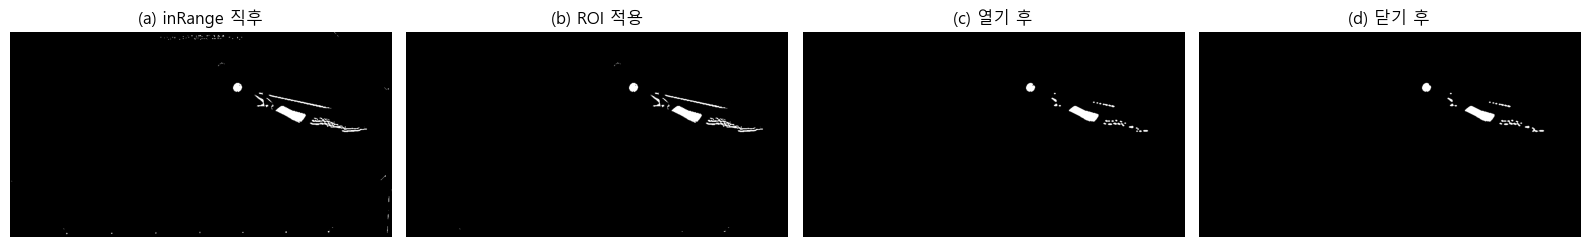

In [36]:


# ====== 흰 공 마스크 단계별  ======
f0 = get_frame(START)
hsv = cv2.cvtColor(f0, cv2.COLOR_BGR2HSV)

mask_raw = cv2.inRange(hsv, WHITE_LO, WHITE_HI)                   # (a) inRange 직후
roi = np.zeros_like(mask_raw); roi[55:f0.shape[0]-15, 35:f0.shape[1]-35] = 255
mask_roi = cv2.bitwise_and(mask_raw, roi)                          # (b) ROI 적용
mask_open = cv2.morphologyEx(mask_roi, cv2.MORPH_OPEN, kernel)     # (c) 열기
mask_close = cv2.morphologyEx(mask_open, cv2.MORPH_CLOSE, kernel)  # (d) 닫기

show_row([mask_raw, mask_roi, mask_open, mask_close],
         ["(a) inRange 직후", "(b) ROI 적용", "(c) 열기 후", "(d) 닫기 후"], gray=True)



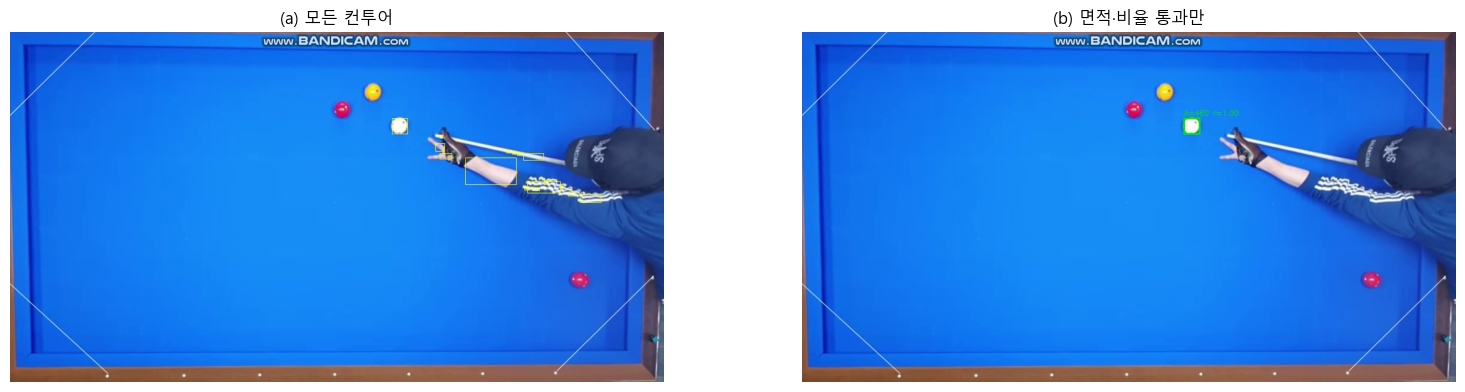

In [37]:

# ====== 컨투어 면적·비율 필터링 전후  ======
cnts, _ = cv2.findContours(mask_close, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

vis_all = f0.copy()                                                # (a) 필터링 전
for c in cnts:
    x, y, bw, bh = cv2.boundingRect(c)
    cv2.rectangle(vis_all, (x, y), (x+bw, y+bh), (0, 255, 255), 1)

vis_kept = f0.copy()                                               # (b) 필터링 후
for c in cnts:
    a = cv2.contourArea(c)
    if not (150 < a < 2600): continue
    x, y, bw, bh = cv2.boundingRect(c)
    if not (0.55 < bw/bh < 1.8): continue
    cv2.rectangle(vis_kept, (x, y), (x+bw, y+bh), (0, 230, 0), 2)
    cv2.putText(vis_kept, f"A={int(a)} r={bw/bh:.2f}", (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 230, 0), 1)

show_row([vis_all, vis_kept], ["(a) 모든 컨투어", "(b) 면적·비율 통과만"])


In [38]:


# ====== 흰 공 검출 함수 정의 ======
def find_white_balls(frame):
    """층1: HSV 이진화 + ROI + 모폴로지 열기/닫기 + 컨투어 + 면적·비율 필터"""
    h, w = frame.shape[:2]
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(hsv, WHITE_LO, WHITE_HI)
    roi = np.zeros_like(mask); roi[55:h-15, 35:w-35] = 255
    mask = cv2.bitwise_and(mask, roi)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    balls = []
    for c in cnts:
        a = cv2.contourArea(c)
        if not (150 < a < 2600): continue
        x, y, bw, bh = cv2.boundingRect(c)
        if not (0.55 < bw/bh < 1.8): continue
        balls.append((a, (x + bw // 2, y + bh // 2)))
    balls.sort(key=lambda b: -b[0])
    return [c for _, c in balls]


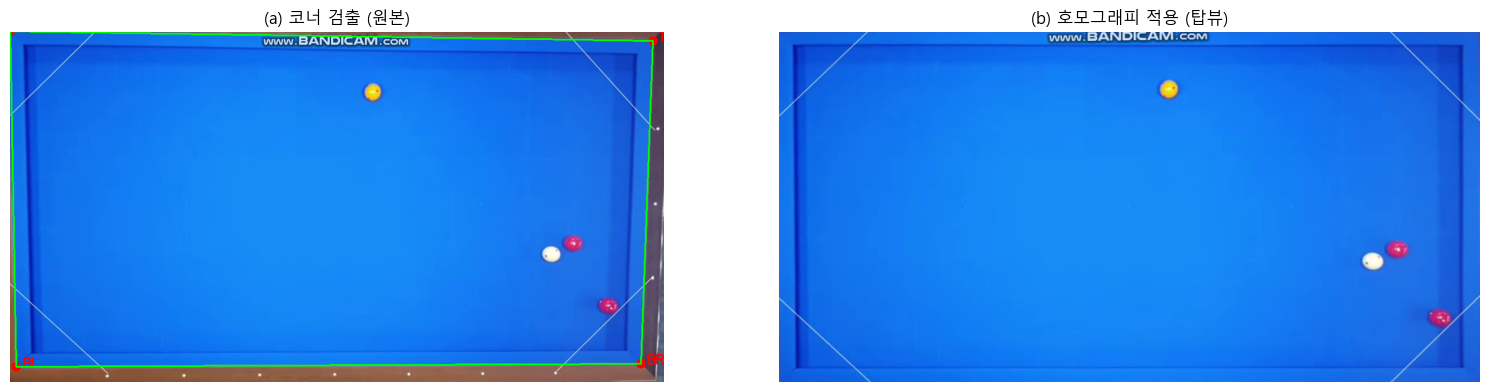

In [39]:


# ====== 호모그래피 전후 ======
def order_corners(pts):
    rect = np.zeros((4, 2), np.float32)
    s = pts.sum(1); d = np.diff(pts, 1).flatten()
    rect[0] = pts[np.argmin(s)]; rect[2] = pts[np.argmax(s)]   # TL, BR
    rect[1] = pts[np.argmin(d)]; rect[3] = pts[np.argmax(d)]   # TR, BL
    return rect

clean = get_frame(CLEAN_FRAME)
blue = cv2.inRange(cv2.cvtColor(clean, cv2.COLOR_BGR2HSV),
                   np.array([95, 90, 60]), np.array([125, 255, 255]))
blue = cv2.morphologyEx(blue, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
cnts, _ = cv2.findContours(blue, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
src = order_corners(max(cnts, key=cv2.contourArea).reshape(-1, 2).astype(np.float32))
dst = np.float32([[0, 0], [TABLE_W, 0], [TABLE_W, TABLE_H], [0, TABLE_H]])
Hmat = cv2.getPerspectiveTransform(src, dst)
table_bg = cv2.warpPerspective(clean, Hmat, (TABLE_W, TABLE_H))

vis_corners = clean.copy()
for i, p in enumerate(src.astype(int)):
    cv2.circle(vis_corners, tuple(p), 8, (0, 0, 255), -1)
    cv2.putText(vis_corners, ["TL","TR","BR","BL"][i],
                tuple(p + np.array([10, 0])),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
cv2.polylines(vis_corners, [src.astype(int)], True, (0, 255, 0), 2)

show_row([vis_corners, table_bg], ["(a) 코너 검출 (원본)", "(b) 호모그래피 적용 (탑뷰)"])

to_top = lambda p: tuple(cv2.perspectiveTransform(
    np.array([[p]], np.float32), Hmat).reshape(2).astype(int))



In [40]:

# ====== 수구 추적 → 원본/탑뷰 궤적 프레임 생성 ======
cap = cv2.VideoCapture(VIDEO_PATH); cap.set(cv2.CAP_PROP_POS_FRAMES, START)
path = []; path_top = []; orig_frames = []; top_frames = []
prev = None; still = 0; count = 0
while count < MAX_FRAMES:
    ok, f = cap.read()
    if not ok: break
    balls = find_white_balls(f)
    if balls:
        prev = balls[0] if prev is None else min(
            balls, key=lambda p: (p[0]-prev[0])**2 + (p[1]-prev[1])**2)
        still = still + 1 if path and (prev[0]-path[-1][0])**2 + (prev[1]-path[-1][1])**2 < 9 else 0
        path.append(prev); path_top.append(to_top(prev))

    vo = f.copy()
    if len(path) >= 2:
        cv2.polylines(vo, [np.array(path, np.int32)], False, (0, 230, 0), 2)
    if path: cv2.circle(vo, path[-1], 10, (0, 230, 0), 2)
    orig_frames.append(vo)

    vt = table_bg.copy()
    if len(path_top) >= 2:
        cv2.polylines(vt, [np.array(path_top, np.int32)], False, (0, 230, 0), 2)
    if path_top: cv2.circle(vt, path_top[-1], 12, (0, 230, 0), 2)
    top_frames.append(vt)

    count += 1
    if still > 20: break
cap.release()
print("추적 끝, 프레임:", len(orig_frames))



추적 끝, 프레임: 138


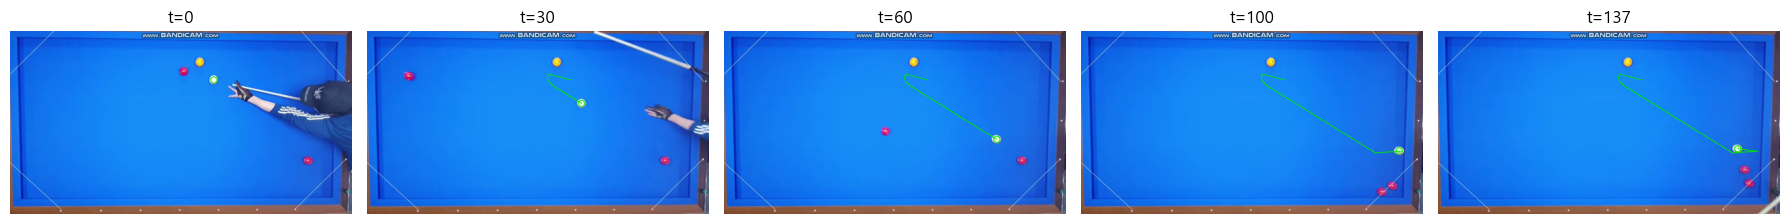

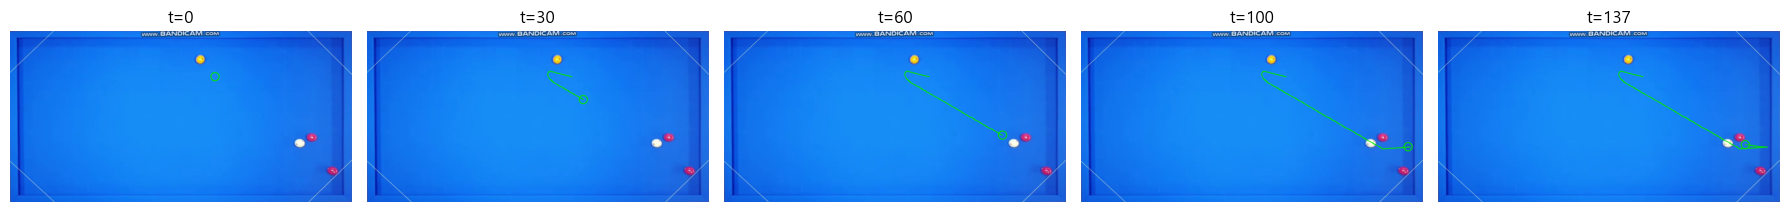

In [41]:

# ====== 층3: 추적 궤적 시간순 스냅샷 ======
SNAPSHOTS = [0, 30, 60, 100, 150, len(orig_frames) - 1]
snaps_orig = [orig_frames[i] for i in SNAPSHOTS if 0 <= i < len(orig_frames)]
snaps_top  = [top_frames[i]  for i in SNAPSHOTS if 0 <= i < len(orig_frames)]
labels = [f"t={i}" for i in SNAPSHOTS if 0 <= i < len(orig_frames)]

show_row(snaps_orig, labels, figsize=(18, 3))    # 원본 시점 시간순
show_row(snaps_top,  labels, figsize=(18, 3))    # 탑뷰 시간순


In [42]:


# ====== [CELL 8] 최종 영상 저장 ======
save_video(orig_frames, "track_original1.mp4")
save_video(top_frames,  "track_topview1.mp4")

[저장] c:\Users\18616\Desktop\StudyPython\VideoProcessingSystem\Project\track_original1.mp4
[저장] c:\Users\18616\Desktop\StudyPython\VideoProcessingSystem\Project\track_topview1.mp4
